In [5]:
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt

# Slope Calculation from TIFF

The goal of this notebook is to calculate a climb's ATES class with a rules-based approach. The climbs' ratings available in the [Ice Climbing Atlas](https://avalanche.ca/resources/ice-climbing/atlas) will validate this tool.

Data downloaded from https://portal.opentopography.org/raster?opentopoID=OTSDEM.032025.3979.1

## Polar Circus

https://avalanche.ca/resources/ice-climbing/atlas/polar-circus

In [26]:
with rasterio.open("../data/polar-circus/output_be.tif") as src:
    dem = src.read(1).astype(float)
    res_x, res_y = src.res  # metres per pixel
    transform = src.transform
    height, width = src.height, src.width


dy, dx = np.gradient(dem, res_y, res_x)
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

x_coords = transform.c + transform.a * np.arange(width)
y_coords = transform.f + transform.e * np.arange(height)
X, Y = np.meshgrid(x_coords, y_coords)

In [27]:
slope_deg

array([[33.14817536, 34.011723  , 35.00803503, ...,  8.77726116,
         7.61822436,  8.4927507 ],
       [34.03177061, 34.61704548, 35.1477009 , ..., 10.50509769,
         7.34166651,  6.94590057],
       [35.39157968, 35.52367853, 35.18894912, ..., 12.27828153,
         8.05164666,  5.83097124],
       ...,
       [ 8.49277621,  8.41515426,  8.92334812, ..., 18.68844623,
        16.60185316, 15.86719048],
       [ 8.53566228,  8.09239316,  7.99171378, ..., 21.74807016,
        18.73029424, 17.31810569],
       [ 8.8717231 ,  8.28047147,  7.94301604, ..., 24.43635174,
        20.78667777, 18.94710086]], shape=(105, 355))

In [30]:
type(X)

numpy.ndarray

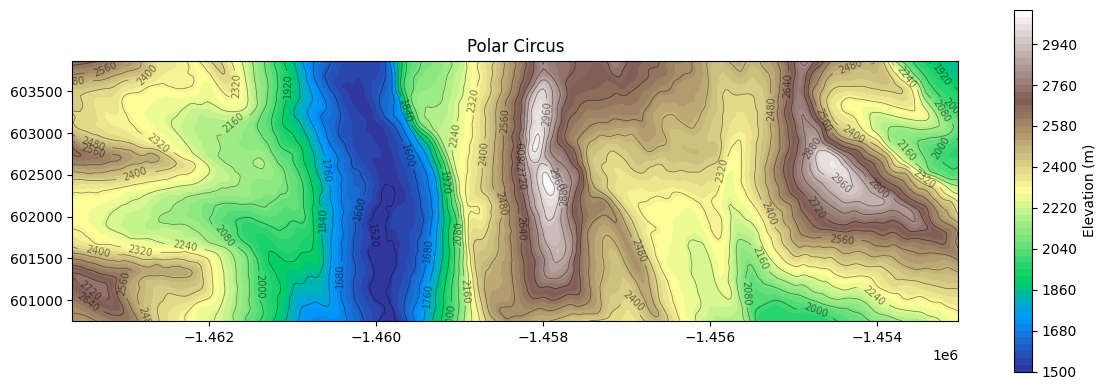

In [34]:
def plot_contour(X: np.ndarray, Y: np.ndarray, title: str):
    _, ax = plt.subplots(figsize=(12, 4))
    contour = ax.contourf(X, Y, dem, levels=60, cmap="terrain")
    contour_lines = ax.contour(
        X, Y, dem, levels=20, colors="black", linewidths=0.5, alpha=0.5
    )
    plt.colorbar(contour, ax=ax, label="Elevation (m)")
    ax.clabel(contour_lines, inline=True, fontsize=7, fmt="%.0f")
    ax.set_title(title)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


plot_contour(X, Y, "Polar Circus")